In [1]:
import random
import torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoImageProcessor, GenerationConfig
from peft import PeftModel
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
    
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "nanoVLM"))

from nanoVLM.models.vision_language_model import VisionLanguageModel

In [2]:
ADAPTER_PATH = PROJECT_ROOT / "checkpoints/sft_adapter"
BASE_MODEL_ID = "lusxvr/nanoVLM-222M"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_PATH)
image_processor = AutoImageProcessor.from_pretrained(ADAPTER_PATH)

In [4]:
base_model = VisionLanguageModel.from_pretrained(BASE_MODEL_ID)

base_model.prepare_inputs_for_generation = lambda *args, **kwargs: kwargs
base_model.generation_config = GenerationConfig()

model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model = model.merge_and_unload()

model = model.to(DEVICE)
model.eval()

VisionLanguageModel(
  (vision_encoder): ViT(
    (patch_embedding): ViTPatchEmbeddings(
      (conv): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
    )
    (dropout): Dropout(p=0.0, inplace=False)
    (blocks): ModuleList(
      (0-11): 12 x ViTBlock(
        (ln1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): ViTMultiHeadAttention(
          (qkv_proj): Linear(in_features=768, out_features=2304, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELU(approximate='tanh')
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
   

In [5]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
dataset_path = PROJECT_ROOT / "minigrid_dataset"

ds = load_from_disk(dataset_path)

print("Размер датасета:", len(ds))

Размер датасета: 5280


In [6]:
import inspect
import types

model.config = getattr(model, "cfg", type('Config', (), {})) 
model.config.model_type = "nanovlm"
model.original_forward = model.forward

def patched_forward(self, **kwargs):
    sig = inspect.signature(self.original_forward)
    accepted_keys = list(sig.parameters.keys())
    
    if 'pixel_values' in kwargs:
        if 'images' in accepted_keys: 
            kwargs['images'] = kwargs.pop('pixel_values')
        elif 'image' in accepted_keys: 
            kwargs['image'] = kwargs.pop('pixel_values')
        elif 'images_tensor' in accepted_keys: 
            kwargs['images_tensor'] = kwargs.pop('pixel_values')
            
    if 'labels' in kwargs:
        if 'targets' in accepted_keys: 
            kwargs['targets'] = kwargs.pop('labels')
        elif 'labels' in accepted_keys: 
            pass

    filtered_kwargs = {k: v for k, v in kwargs.items() if k in accepted_keys}
    return self.original_forward(**filtered_kwargs)

model.forward = types.MethodType(patched_forward, model)

In [7]:
def predict_action(image, prompt, max_new_tokens=1):
    text = f"User: <image>\n{prompt}\nAssistant: "
    
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]

    image_inputs = image_processor(
        image, 
        return_tensors="pt", 
        do_resize=True, 
        size={"height": 224, "width": 224},
    )
    pixel_values = image_inputs.pixel_values.to(torch.float32).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids, 
            pixel_values, 
            max_new_tokens=max_new_tokens
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

    raw_output = generated_text.lower()
    if "left" in raw_output:
        return "left", generated_text
    elif "right" in raw_output:
        return "right", generated_text
    elif "forward" in raw_output:
        return "forward", generated_text
    
    return None, generated_text


=== Пример 1 ===


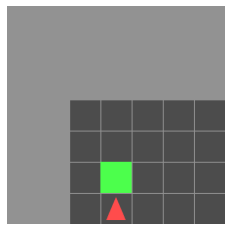

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 2 ===


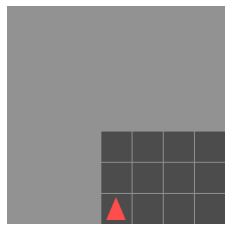

True action: right
Predicted: forward
Raw output: forward

=== Пример 3 ===


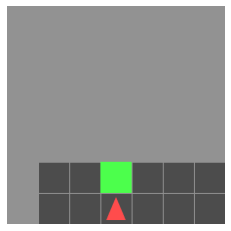

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 4 ===


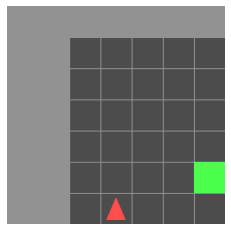

True action: forward
Predicted: forward
Raw output: forward

=== Пример 5 ===


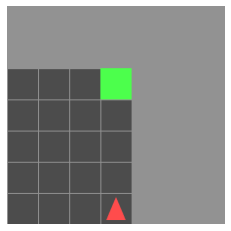

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 6 ===


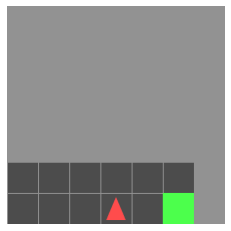

True action: right
Predicted: forward
Raw output: Forward

=== Пример 7 ===


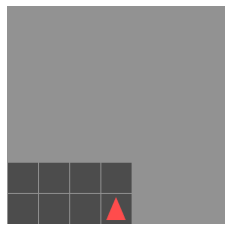

True action: left
Predicted: left
Raw output: Left

=== Пример 8 ===


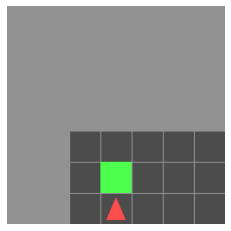

True action: forward
Predicted: forward
Raw output: Forward

=== Пример 9 ===


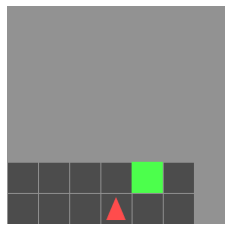

True action: forward
Predicted: forward
Raw output: forward

=== Пример 10 ===


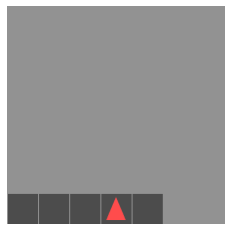

True action: left
Predicted: forward
Raw output: forward

Accuracy: 7/10 = 0.70


In [8]:
indices = random.sample(range(len(ds)), 10)

correct = 0

for i, idx in enumerate(indices):
    item = ds[idx]

    image = item["ego_image"].convert("RGB")
    prompt = item["prompt"]
    true_action = item["action"]

    pred_action, raw_output = predict_action(image, prompt)

    print(f"\n=== Пример {i+1} ===")
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("True action:", true_action)
    print("Predicted:", pred_action)
    print("Raw output:", raw_output)

    if pred_action == true_action:
        correct += 1

print("\n======================")
print(f"Accuracy: {correct}/10 = {correct/10:.2f}")